# Responsible-AI audit of a depression-risk model

This notebook trains three risk models on the pooled NHANES tabular data and audits the
explanation, fairness, and calibration tools applied to them. It runs for a single seed and
saves every model, result table, and figure under `seed_<SEED>/`.

Only the seed cell below is changed between runs (seeds 21 to 30). Run the notebook top to
bottom. All results print as text tables so they can be read directly in the cell outputs,
and all figures render inline as well as saving to PNG (600 dpi) and SVG.#%% md


In [1]:
SEED = 21

## Environment and configuration

Imports, output folders derived from the seed, a figure saver that writes both formats, and
the evaluation subset sizes used for the explanation analyses.

In [2]:
import os, json, warnings, joblib
import numpy as np, pandas as pd
from scipy.optimize import minimize_scalar
from scipy.stats import spearmanr, kendalltau
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score
import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
%matplotlib inline

TRAPZ = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
DATA = '../data/nhanes_depression_modelready.csv'
OUT = f'seed_{SEED}'
EVAL_N = 200   # instances for SHAP, agreement, faithfulness
LIME_N = 120   # instances for LIME, which is slower
N_BINS = 15

rng = np.random.default_rng(SEED)
np.random.seed(SEED)
for d in ['models', 'figures', 'results']:
    os.makedirs(f'{OUT}/{d}', exist_ok=True)

def savefig(fig, name):
    fig.savefig(f'{OUT}/figures/{name}.png', dpi=600, bbox_inches='tight')
    fig.savefig(f'{OUT}/figures/{name}.svg', bbox_inches='tight')
    plt.show()

print('seed', SEED, '| output ->', OUT)

seed 21 | output -> seed_21


## Data and leakage control

The nine PHQ items and the impairment item define the label and are never present as
features. This cell asserts that, then drops any numeric feature missing in more than 40% of
rows. Age and income bands are held aside as protected attributes only.

In [3]:
df = pd.read_csv(DATA)
LEAK = [f'DPQ0{i}0' for i in range(1, 10)] + ['DPQ100']
assert not set(LEAK) & set(df.columns), 'leakage: PHQ items present as columns'
TARGET = 'mdd'

miss = df.select_dtypes('number').isna().mean()
dropped = [c for c in ['glucose_fasting', 'triglyceride', 'ldl']
           if c in df.columns and miss.get(c, 0) > 0.40]

NUM = ['age','income_pir','education','bmi','waist','sbp','dbp','wbc','haemoglobin','platelets',
 'neutrophil_pct','lymphocyte_pct','nlr','hba1c','hdl','total_chol','current_smoker','sleep_hours',
 'sedentary_min','diabetes','high_bp_hx','high_chol_hx','chd_hx','stroke_hx','cancer_hx','gen_health']
NUM = [c for c in NUM if c not in dropped]
CAT = ['sex', 'race']
PROT = ['sex', 'race', 'age_band', 'income_band']
FEATURES = NUM + CAT

print('rows', len(df), '| positive rate', round(df[TARGET].mean(), 4))
print('dropped (>40% missing):', dropped)
print('model features:', len(FEATURES))
print(df.groupby('cycle')[TARGET].mean().round(4).to_string())

rows 36259 | positive rate 0.0874
dropped (>40% missing): ['glucose_fasting', 'triglyceride', 'ldl']
model features: 28
cycle
2005-2006    0.0619
2007-2008    0.0966
2009-2010    0.0943
2011-2012    0.0893
2013-2014    0.0951
2015-2016    0.0808
2017-2018    0.0906


## Split regimes

Three regimes. In-distribution is a stratified split of the pooled data. Temporal shift
trains on 2005 to 2014 and tests on 2015 to 2018. Subgroup shift trains on ages 18 to 49 and
tests on 65 and over. Each seed produces one realisation of every split, and the ten seeds
supply the repetition that variance estimates need.

In [4]:
def make_splits(df):
    idx = df.index.to_numpy(); y = df[TARGET].to_numpy(); reg = {}
    tr, te = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)
    tr, va = train_test_split(tr, test_size=0.25, stratify=y[np.isin(idx, tr)], random_state=SEED)
    reg['id'] = dict(train=tr, val=va, test=te)

    trc = df['cycle'].isin(['2005-2006','2007-2008','2009-2010','2011-2012','2013-2014'])
    tec = df['cycle'].isin(['2015-2016','2017-2018'])
    tr_all = idx[trc.to_numpy()]; te_t = idx[tec.to_numpy()]
    tr, va = train_test_split(tr_all, test_size=0.2, stratify=df.loc[tr_all, TARGET], random_state=SEED)
    reg['shift_time'] = dict(train=tr, val=va, test=te_t)

    trg = df['age_band'].isin(['18-34','35-49']); teg = df['age_band'].eq('65+')
    tr_all = idx[trg.to_numpy()]; te_s = idx[teg.to_numpy()]
    tr, va = train_test_split(tr_all, test_size=0.2, stratify=df.loc[tr_all, TARGET], random_state=SEED)
    reg['shift_age'] = dict(train=tr, val=va, test=te_s)
    return reg

def build_prep(train_df):
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUM),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CAT)])
    pre.fit(train_df[FEATURES])
    names = [n.split('__', 1)[1] for n in pre.get_feature_names_out()]
    return pre, names

def to_frame(pre, X, names):
    return pd.DataFrame(pre.transform(X[FEATURES]), columns=names, index=X.index)

splits = make_splits(df)
for k, v in splits.items():
    print(k, 'train', len(v['train']), 'val', len(v['val']), 'test', len(v['test']))

id train 21755 val 7252 test 7252
shift_time train 20845 val 5212 test 10202
shift_age train 15398 val 3850 test 8170


## Models

Logistic regression, random forest, and gradient boosting. Class weighting is applied to
each to counter the 8.7% base rate. The imputer, scaler, and encoder are fit on the training
split only.

In [5]:
def make_models(y_train):
    pos = y_train.sum(); neg = len(y_train) - pos; spw = neg / max(pos, 1)
    return {
        'logreg': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
        'rf': RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=SEED),
        'xgb': xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9,
                colsample_bytree=0.9, scale_pos_weight=spw, eval_metric='logloss',
                random_state=SEED, n_jobs=-1)}

## Metrics and calibration

Discrimination, calibration error, and proper scores, plus a reliability table returned for
plotting. Temperature, Platt, and isotonic calibrators are fit on the validation split.

In [6]:
def ece_mce(p, y, n_bins=N_BINS):
    bins = np.linspace(0, 1, n_bins + 1); ece = 0; mce = 0; rows = []
    for i in range(n_bins):
        m = (p > bins[i]) & (p <= bins[i+1]) if i > 0 else (p >= bins[i]) & (p <= bins[i+1])
        if m.sum() == 0:
            rows.append((i, bins[i], bins[i+1], 0, np.nan, np.nan)); continue
        conf = p[m].mean(); acc = y[m].mean(); w = m.mean()
        ece += w * abs(acc - conf); mce = max(mce, abs(acc - conf))
        rows.append((i, bins[i], bins[i+1], int(m.sum()), conf, acc))
    rel = pd.DataFrame(rows, columns=['bin','lo','hi','n','confidence','accuracy'])
    return ece, mce, rel

def brier(p, y): return np.mean((p - y) ** 2)
def nll(p, y): p = np.clip(p, 1e-6, 1-1e-6); return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

def all_metrics(p, y):
    yhat = (p >= 0.5).astype(int); e, m, _ = ece_mce(p, y)
    return dict(acc=accuracy_score(y, yhat), roc=roc_auc_score(y, p), pr=average_precision_score(y, p),
                ece=e, mce=m, brier=brier(p, y), nll=nll(p, y), mean_conf=np.maximum(p, 1-p).mean())

def _logit(p): p = np.clip(p, 1e-6, 1-1e-6); return np.log(p / (1-p))

def fit_temperature(p_val, y):
    z = _logit(p_val)
    def obj(T):
        q = np.clip(1/(1+np.exp(-z/T)), 1e-6, 1-1e-6)
        return -np.mean(y*np.log(q) + (1-y)*np.log(1-q))
    return minimize_scalar(obj, bounds=(0.05, 10), method='bounded').x

def apply_temperature(p, T): return 1/(1+np.exp(-_logit(p)/T))
def fit_platt(p_val, y):
    lr = LogisticRegression(); lr.fit(_logit(p_val).reshape(-1,1), y); return lr
def apply_platt(p, lr): return lr.predict_proba(_logit(p).reshape(-1,1))[:,1]
def fit_isotonic(p_val, y):
    ir = IsotonicRegression(out_of_bounds='clip'); ir.fit(p_val, y); return ir

## Explanation methods

TreeSHAP for the tree models and LinearSHAP for logistic regression, tabular LIME, their
rank agreement, deletion and insertion faithfulness, and a perturbation stability index
contrasted with prediction stability under the same noise.

In [7]:
def shap_values(model, name, Xbg, Xev):
    if name == 'logreg':
        v = shap.LinearExplainer(model, Xbg).shap_values(Xev)
    else:
        v = shap.TreeExplainer(model).shap_values(Xev, check_additivity=False)
    v = np.asarray(v)
    if v.ndim == 3:
        v = v[:, :, 1] if v.shape[-1] == 2 else v[:, :, 0]
    return v

def lime_global(model, Xtr, Xev, names):
    ex = LimeTabularExplainer(Xtr.values, feature_names=names, class_names=['no','mdd'],
                              mode='classification', discretize_continuous=True, random_state=SEED)
    imp = np.zeros(len(names))
    for i in range(len(Xev)):
        e = ex.explain_instance(Xev.values[i], model.predict_proba, num_features=len(names))
        for fidx, w in e.as_map()[1]:
            imp[fidx] += abs(w)
    return imp / len(Xev)

def agreement(shap_abs, lime_abs, names, k=10):
    rs = pd.Series(shap_abs).rank(ascending=False); rl = pd.Series(lime_abs).rank(ascending=False)
    sp = spearmanr(shap_abs, lime_abs).correlation; kt = kendalltau(shap_abs, lime_abs).correlation
    tsh = set(np.argsort(shap_abs)[::-1][:k]); tli = set(np.argsort(lime_abs)[::-1][:k])
    jac = len(tsh & tli) / len(tsh | tli)
    tab = pd.DataFrame({'feature': names, 'shap_absmean': shap_abs, 'lime_absmean': lime_abs,
                        'shap_rank': rs.values, 'lime_rank': rl.values}).sort_values('shap_rank')
    return dict(spearman=sp, kendall=kt, topk_jaccard=jac), tab

def faithfulness(model, Xev, attr):
    X = Xev.values.copy(); base = np.zeros(X.shape[1]); nf = X.shape[1]
    order = np.argsort(-np.abs(attr), axis=1)
    steps = list(range(0, nf + 1, max(1, nf // 10)))
    prob = lambda A: model.predict_proba(A)[:, 1]
    dele, ins = [], []
    for s in steps:
        Xd = X.copy(); Xi = np.tile(base, (len(X), 1)).astype(float)
        for r in range(len(X)):
            Xd[r, order[r, :s]] = base[order[r, :s]]
            Xi[r, order[r, :s]] = X[r, order[r, :s]]
        dele.append(prob(Xd).mean()); ins.append(prob(Xi).mean())
    fr = np.array(steps) / nf
    return (dict(deletion_auc=TRAPZ(dele, fr), insertion_auc=TRAPZ(ins, fr)),
            pd.DataFrame({'frac': fr, 'deletion': dele, 'insertion': ins}))

def perturb_stability(model, name, Xbg, Xev, sigma=0.1, reps=3):
    base = shap_values(model, name, Xbg, Xev); p0 = model.predict_proba(Xev)[:, 1]
    scors, pdiffs = [], []
    for _ in range(reps):
        Xn = Xev + rng.normal(0, sigma, Xev.shape)
        vn = shap_values(model, name, Xbg, pd.DataFrame(Xn, columns=Xev.columns, index=Xev.index))
        for r in range(len(Xev)):
            sc = spearmanr(np.abs(base[r]), np.abs(vn[r])).correlation
            if not np.isnan(sc): scors.append(sc)
        pdiffs.append(np.abs(model.predict_proba(Xn)[:, 1] - p0).mean())
    return dict(expl_stability=np.mean(scors), pred_shift=np.mean(pdiffs))

## Fairness and uncertainty

Per-group rates and errors, a reweighing step used later to test interaction, predictive
entropy, and a risk-coverage curve for selective prediction.

In [8]:
def group_metrics(p, y, groups, thr=0.5):
    yhat = (p >= thr).astype(int); rows = []
    for g in pd.unique(groups):
        m = groups == g
        if m.sum() < 20: continue
        yy, pp, hh = y[m], p[m], yhat[m]
        tp = ((hh==1)&(yy==1)).sum(); fn = ((hh==0)&(yy==1)).sum()
        fp = ((hh==1)&(yy==0)).sum(); tn = ((hh==0)&(yy==0)).sum()
        e, _, _ = ece_mce(pp, yy)
        rows.append((str(g), int(m.sum()), float(yy.mean()), hh.mean(),
                     tp/max(tp+fn,1), fp/max(fp+tn,1), precision_score(yy, hh, zero_division=0), e))
    t = pd.DataFrame(rows, columns=['group','n','base_rate','selection','tpr','fpr','precision','ece'])
    gaps = dict(dp_diff=t.selection.max()-t.selection.min(), tpr_gap=t.tpr.max()-t.tpr.min(),
                fpr_gap=t.fpr.max()-t.fpr.min(), ece_gap=t.ece.max()-t.ece.min())
    return t, gaps

def reweigh_weights(y, group):
    w = np.ones(len(y)); d = pd.DataFrame({'y': y, 'g': group})
    for (gg, yy), idx in d.groupby(['g','y']).groups.items():
        obs = len(idx)/len(d); exp = d.g.eq(gg).mean() * d.y.eq(yy).mean()
        w[list(idx)] = exp / max(obs, 1e-9)
    return w

def entropy(p): p = np.clip(p, 1e-9, 1-1e-9); return -(p*np.log(p) + (1-p)*np.log(1-p))

def risk_coverage(p, y):
    conf = np.maximum(p, 1-p); order = np.argsort(-conf); ys = y[order]; ph = (p[order] >= 0.5).astype(int)
    cov, acc = [], []
    for frac in np.linspace(0.1, 1.0, 10):
        k = max(int(frac*len(y)), 1); cov.append(frac); acc.append((ph[:k] == ys[:k]).mean())
    return pd.DataFrame({'coverage': cov, 'accuracy': acc})

## Train all models across regimes

Each model is fit per regime, saved, and evaluated raw and under the three calibrators. The
performance table is the reference for the discrimination and calibration claims: watch the
raw ECE and mean confidence, and how the calibrators behave in distribution versus under
shift.

In [9]:
store = {}; perf_rows = []; reliab = {}
for reg, sp in splits.items():
    tr, va, te = df.loc[sp['train']], df.loc[sp['val']], df.loc[sp['test']]
    pre, names = build_prep(tr)
    Xtr, Xva, Xte = to_frame(pre, tr, names), to_frame(pre, va, names), to_frame(pre, te, names)
    ytr, yva, yte = tr[TARGET].to_numpy(), va[TARGET].to_numpy(), te[TARGET].to_numpy()
    store[reg] = {}
    for mname, model in make_models(ytr).items():
        model.fit(Xtr, ytr)
        joblib.dump(model, f'{OUT}/models/{reg}_{mname}.joblib')
        p_te = model.predict_proba(Xte)[:, 1]; p_va = model.predict_proba(Xva)[:, 1]
        store[reg][mname] = dict(model=model, Xtr=Xtr, Xva=Xva, Xte=Xte, yte=yte, p_raw=p_te, names=names)
        row = all_metrics(p_te, yte); row.update(regime=reg, model=mname, calib='raw'); perf_rows.append(row)
        _, _, rel = ece_mce(p_te, yte); reliab[(reg, mname)] = rel
        T = fit_temperature(p_va, yva); pl = fit_platt(p_va, yva); iso = fit_isotonic(p_va, yva)
        store[reg][mname]['T'] = T
        for cname, pc in [('temp', apply_temperature(p_te, T)), ('platt', apply_platt(p_te, pl)),
                          ('isotonic', iso.predict(p_te))]:
            r = all_metrics(pc, yte); r.update(regime=reg, model=mname, calib=cname); perf_rows.append(r)

perf = pd.DataFrame(perf_rows)[['regime','model','calib','acc','roc','pr','ece','mce','brier','nll','mean_conf']].round(4)
perf.to_csv(f'{OUT}/results/performance.csv', index=False)
print(perf.to_string(index=False))

    regime  model    calib    acc    roc     pr    ece    mce  brier    nll  mean_conf
        id logreg      raw 0.7133 0.7858 0.3138 0.3050 0.5259 0.1861 0.5509     0.7206
        id logreg     temp 0.7133 0.7858 0.3138 0.3080 0.5248 0.1861 0.5510     0.7137
        id logreg    platt 0.9138 0.7858 0.3138 0.0077 0.0726 0.0697 0.2492     0.9148
        id logreg isotonic 0.9138 0.7845 0.2973 0.0036 0.1249 0.0695 0.2488     0.9152
        id     rf      raw 0.9084 0.7889 0.2817 0.0760 0.8200 0.0781 0.2791     0.8412
        id     rf     temp 0.9084 0.7889 0.2817 0.0222 0.8909 0.0727 0.2557     0.8999
        id     rf    platt 0.9123 0.7889 0.2817 0.0093 0.6943 0.0709 0.2509     0.9148
        id     rf isotonic 0.9123 0.7846 0.2554 0.0064 1.0000 0.0714 0.2555     0.9161
        id    xgb      raw 0.7774 0.7904 0.3061 0.2525 0.5038 0.1544 0.4737     0.7465
        id    xgb     temp 0.7774 0.7904 0.3061 0.2373 0.5109 0.1533 0.4694     0.7732
        id    xgb    platt 0.9130 0.7904 0.

## Reliability

Per-bin confidence against accuracy for XGBoost, in distribution and under age shift. The bin
tables carry the same information as the diagram.


reliability xgb id
 bin     lo     hi    n  confidence  accuracy
   0 0.0000 0.0667  527      0.0480    0.0095
   1 0.0667 0.1333 1045      0.0988    0.0182
   2 0.1333 0.2000  986      0.1659    0.0213
   3 0.2000 0.2667  837      0.2326    0.0502
   4 0.2667 0.3333  712      0.2995    0.0492
   5 0.3333 0.4000  605      0.3657    0.0628
   6 0.4000 0.4667  523      0.4318    0.0841
   7 0.4667 0.5333  440      0.5003    0.0932
   8 0.5333 0.6000  381      0.5662    0.1575
   9 0.6000 0.6667  338      0.6337    0.1657
  10 0.6667 0.7333  295      0.6987    0.2373
  11 0.7333 0.8000  248      0.7659    0.2621
  12 0.8000 0.8667  175      0.8308    0.4229
  13 0.8667 0.9333  120      0.8967    0.4250
  14 0.9333 1.0000   20      0.9466    0.6500

reliability xgb shift_age
 bin     lo     hi    n  confidence  accuracy
   0 0.0000 0.0667  688      0.0487    0.0087
   1 0.0667 0.1333 1409      0.0987    0.0142
   2 0.1333 0.2000 1172      0.1655    0.0273
   3 0.2000 0.2667  944      0.23

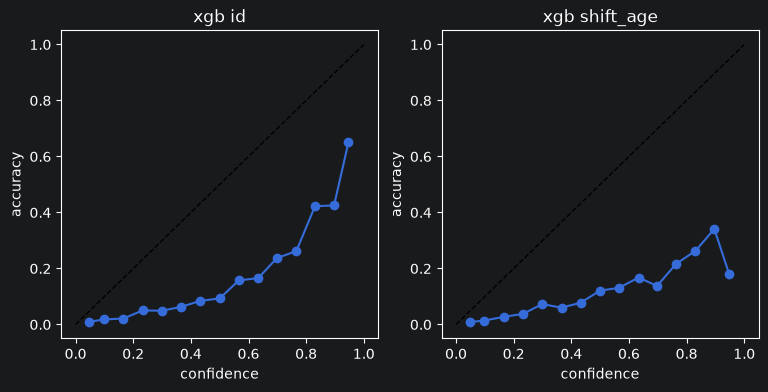

In [10]:
for reg in ['id', 'shift_age']:
    print(f'\nreliability xgb {reg}')
    print(reliab[(reg, 'xgb')].dropna().round(4).to_string(index=False))

print('\nECE by regime and model (raw)')
print(perf[perf.calib == 'raw'].pivot_table(index='model', columns='regime', values='ece').round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, reg in zip(axes, ['id', 'shift_age']):
    r = reliab[(reg, 'xgb')].dropna()
    ax.plot([0, 1], [0, 1], 'k--', lw=1); ax.plot(r.confidence, r.accuracy, 'o-')
    ax.set_title(f'xgb {reg}'); ax.set_xlabel('confidence'); ax.set_ylabel('accuracy')
savefig(fig, 'reliability_id_vs_shift_xgb')

## Explanation reliability

For each model in distribution: SHAP against LIME rank agreement, deletion and insertion
faithfulness, and stability. `expl_stability` near 1 means attributions barely move under
small input noise; compare it against `pred_shift`, the change in predicted probability under
the same noise.


logreg: top-8 by SHAP rank
       feature  shap_absmean  lime_absmean  shap_rank  lime_rank
    gen_health        0.6495        0.2186        1.0        1.0
    income_pir        0.2981        0.0715        2.0        5.0
           age        0.2348        0.0609        3.0        7.0
current_smoker        0.2318        0.0946        4.0        2.0
      sex_Male        0.2272        0.0892        5.0        3.0
   sleep_hours        0.1453        0.0417        6.0        9.0
neutrophil_pct        0.1268        0.0379        7.0       10.0
 sedentary_min        0.1231        0.0329        8.0       12.0

rf: top-8 by SHAP rank
       feature  shap_absmean  lime_absmean  shap_rank  lime_rank
    gen_health        0.1020        0.0689        1.0        1.0
    income_pir        0.0448        0.0266        2.0        3.0
   sleep_hours        0.0358        0.0245        3.0        4.0
current_smoker        0.0349        0.0439        4.0        2.0
           bmi        0.0179        0.

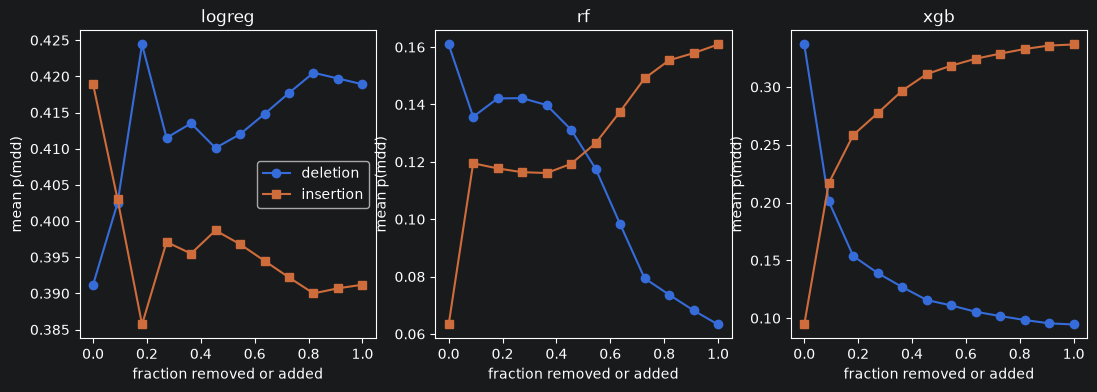

In [11]:
expl_summary = []; shap_ref = {}
for mname in ['logreg', 'rf', 'xgb']:
    s = store['id'][mname]; model = s['model']
    ev = s['Xte'].iloc[:EVAL_N]; bg = s['Xtr'].iloc[:100]; names = s['names']
    sv = shap_values(model, mname, bg, ev); shap_abs = np.abs(sv).mean(0)
    lim = lime_global(model, s['Xtr'], ev.iloc[:LIME_N], names)
    ag, tab = agreement(shap_abs, lim, names); fa, curve = faithfulness(model, ev, sv)
    st = perturb_stability(model, mname, bg, ev.iloc[:100])
    tab.round(4).to_csv(f'{OUT}/results/agreement_{mname}.csv', index=False)
    curve.round(4).to_csv(f'{OUT}/results/faithfulness_{mname}.csv', index=False)
    shap_ref[mname] = pd.Series(shap_abs, index=names)
    expl_summary.append(dict(model=mname, **ag, **fa, **st))
    print(f'\n{mname}: top-8 by SHAP rank')
    print(tab.head(8).round(4).to_string(index=False))

es = pd.DataFrame(expl_summary).round(4); es.to_csv(f'{OUT}/results/explanation_summary.csv', index=False)
print('\nexplanation summary')
print(es.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m in zip(axes, ['logreg', 'rf', 'xgb']):
    c = pd.read_csv(f'{OUT}/results/faithfulness_{m}.csv')
    ax.plot(c.frac, c.deletion, 'o-', label='deletion'); ax.plot(c.frac, c.insertion, 's-', label='insertion')
    ax.set_title(m); ax.set_xlabel('fraction removed or added'); ax.set_ylabel('mean p(mdd)')
axes[0].legend(); savefig(fig, 'faithfulness_curves')

## Explanation drift

Global SHAP importance for XGBoost, ranked in distribution and re-ranked under each shift.
Low rank correlation or low top-k overlap means the drivers you would report from the
in-distribution explanation no longer hold on the shifted population.


shift_time: rank change (top 8 by id rank)
                id_rank  shift_rank  delta
gen_health          1.0         1.0    0.0
income_pir          2.0         2.0    0.0
sleep_hours         3.0         3.0    0.0
sex_Female          4.0         4.0    0.0
current_smoker      5.0         6.0    1.0
age                 6.0         5.0   -1.0
sedentary_min       7.0         8.0    1.0
sbp                 8.0         7.0   -1.0

shift_age: rank change (top 8 by id rank)
                id_rank  shift_rank  delta
gen_health          1.0         1.0    0.0
income_pir          2.0         4.0    2.0
sleep_hours         3.0         5.0    2.0
sex_Female          4.0         7.0    3.0
current_smoker      5.0         6.0    1.0
age                 6.0         2.0   -4.0
sedentary_min       7.0        21.0   14.0
sbp                 8.0         3.0   -5.0

drift summary
    regime  spearman_vs_id  topk_jaccard_vs_id
shift_time          0.9001              0.6667
 shift_age          0.8600    

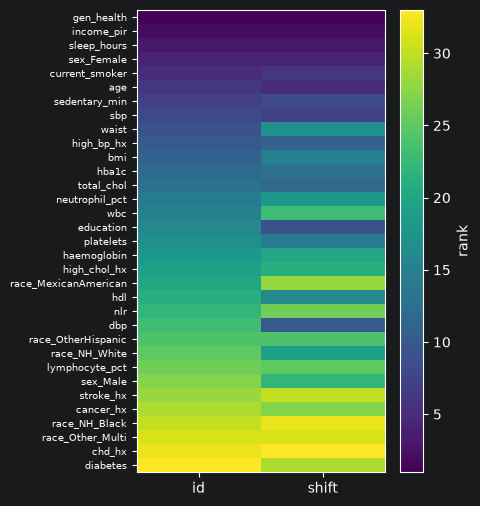

In [12]:
drift_rows = []
for reg in ['shift_time', 'shift_age']:
    s = store[reg]['xgb']; ev = s['Xte'].iloc[:EVAL_N]; bg = s['Xtr'].iloc[:100]
    imp = pd.Series(np.abs(shap_values(s['model'], 'xgb', bg, ev)).mean(0), index=s['names'])
    base = shap_ref['xgb']
    sp = spearmanr(base.values, imp.reindex(base.index).values).correlation
    tsh = set(base.sort_values(ascending=False).head(10).index)
    tsi = set(imp.sort_values(ascending=False).head(10).index)
    drift_rows.append(dict(regime=reg, spearman_vs_id=sp, topk_jaccard_vs_id=len(tsh & tsi)/len(tsh | tsi)))
    cmp = pd.DataFrame({'id_rank': base.rank(ascending=False),
                        'shift_rank': imp.reindex(base.index).rank(ascending=False)})
    cmp['delta'] = cmp.shift_rank - cmp.id_rank
    cmp = cmp.sort_values('id_rank')
    cmp.round(2).to_csv(f'{OUT}/results/drift_{reg}.csv')
    print(f'\n{reg}: rank change (top 8 by id rank)')
    print(cmp.head(8).round(2).to_string())

dr = pd.DataFrame(drift_rows).round(4)
print('\ndrift summary'); print(dr.to_string(index=False))

d = pd.read_csv(f'{OUT}/results/drift_shift_time.csv', index_col=0)
fig, ax = plt.subplots(figsize=(4, 6))
im = ax.imshow(d[['id_rank', 'shift_rank']].values, aspect='auto', cmap='viridis')
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=7)
ax.set_xticks([0, 1]); ax.set_xticklabels(['id', 'shift']); fig.colorbar(im, ax=ax, label='rank')
savefig(fig, 'drift_heatmap_shift_time')

## Fairness

Per-group selection rate, true and false positive rates, precision, and subgroup calibration
error, in distribution. The gap summary is the max minus min across groups for each metric
and model. Subgroup calibration error is the part most fairness reporting omits.


xgb sex
 group    n  base_rate  selection    tpr    fpr  precision    ece
Female 3727     0.1116     0.3236 0.7067 0.2754     0.2438 0.2805
  Male 3525     0.0618     0.1679 0.5275 0.1442     0.1943 0.2229

xgb race
          group    n  base_rate  selection    tpr    fpr  precision    ece
MexicanAmerican 1145     0.0856     0.2672 0.6020 0.2359     0.1928 0.2845
  OtherHispanic  687     0.1223     0.3581 0.7143 0.3085     0.2439 0.2961
    Other_Multi  759     0.0487     0.1752 0.7297 0.1468     0.2030 0.2398
       NH_White 3050     0.0879     0.2282 0.6306 0.1894     0.2428 0.2277
       NH_Black 1611     0.0912     0.2588 0.6395 0.2206     0.2254 0.2643

xgb age_band
group    n  base_rate  selection    tpr    fpr  precision    ece
35-49 1681     0.1023     0.2748 0.7035 0.2260     0.2619 0.2524
50-64 1776     0.1104     0.3221 0.7857 0.2646     0.2692 0.2721
18-34 2165     0.0661     0.2189 0.5245 0.1973     0.1582 0.2742
  65+ 1630     0.0755     0.1779 0.4797 0.1533     0.2034 0

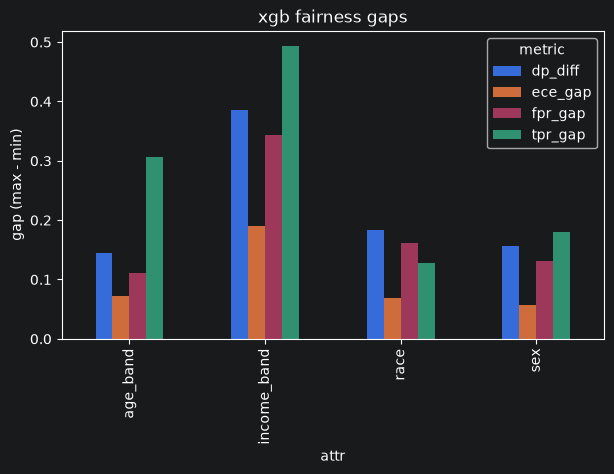

In [13]:
fair_all = []
for mname in ['logreg', 'rf', 'xgb']:
    s = store['id'][mname]; te = df.loc[splits['id']['test']]; p, y = s['p_raw'], s['yte']
    for attr in PROT:
        t, gaps = group_metrics(p, y, te[attr].astype(str).to_numpy())
        for k, v in gaps.items():
            fair_all.append(dict(model=mname, attr=attr, metric=k, value=round(v, 4)))
        if mname == 'xgb':
            print(f'\nxgb {attr}'); print(t.round(4).to_string(index=False))

fair = pd.DataFrame(fair_all); fair.to_csv(f'{OUT}/results/fairness_gaps.csv', index=False)
print('\nfairness gap summary')
print(fair.pivot_table(index=['model','attr'], columns='metric', values='value').round(4).to_string())

piv = fair[fair.model == 'xgb'].pivot_table(index='attr', columns='metric', values='value')
fig, ax = plt.subplots(figsize=(7, 4)); piv.plot(kind='bar', ax=ax)
ax.set_ylabel('gap (max - min)'); ax.set_title('xgb fairness gaps')
savefig(fig, 'fairness_gaps_xgb')

## Interaction experiments

Two tests of whether fixing one property disturbs another. First, reweighing on race,
retrained on logistic regression, and its effect on the fairness gaps, the overall
calibration, and the SHAP top-10. Second, whether a single global temperature moves subgroup
calibration error unevenly across groups.

reweighing (logreg, race)
 state  tpr_gap  dp_diff  overall_ece
before   0.1667   0.2647       0.3050
 after   0.1680   0.0817       0.3057
SHAP top-10 Jaccard before vs after: 1.0

global temperature T = 0.845
          group    n  ece_raw  ece_tempscaled
MexicanAmerican 1145   0.2845          0.2705
  OtherHispanic  687   0.2961          0.2867
    Other_Multi  759   0.2398          0.2202
       NH_White 3050   0.2277          0.2114
       NH_Black 1611   0.2643          0.2498


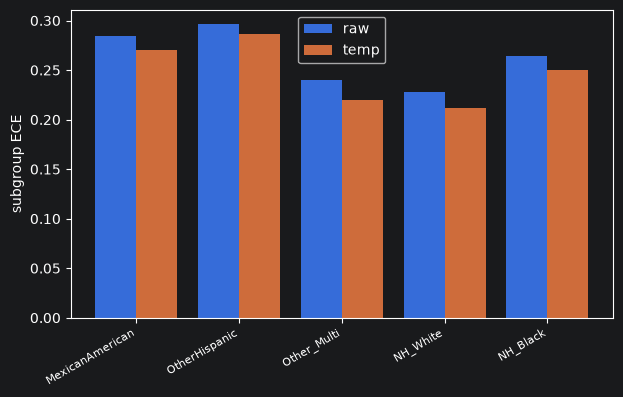

In [14]:
tr = df.loc[splits['id']['train']]; te = df.loc[splits['id']['test']]
s = store['id']['logreg']; Xtr, Xte, yte = s['Xtr'], s['Xte'], s['yte']; ytr = tr[TARGET].to_numpy()
w = reweigh_weights(ytr, tr['race'].astype(str).to_numpy())
# baseline and debiased share class_weight; the only difference is the reweighing sample weights
m2 = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
m2.fit(Xtr, ytr, sample_weight=w)
p1 = s['p_raw']; p2 = m2.predict_proba(Xte)[:, 1]
_, g1 = group_metrics(p1, yte, te['race'].astype(str).to_numpy())
_, g2 = group_metrics(p2, yte, te['race'].astype(str).to_numpy())
e1, _, _ = ece_mce(p1, yte); e2, _, _ = ece_mce(p2, yte)
sv1 = np.abs(shap_values(s['model'], 'logreg', Xtr.iloc[:100], Xte.iloc[:EVAL_N])).mean(0)
sv2 = np.abs(shap_values(m2, 'logreg', Xtr.iloc[:100], Xte.iloc[:EVAL_N])).mean(0)
t1 = set(np.argsort(sv1)[::-1][:10]); t2 = set(np.argsort(sv2)[::-1][:10])
inter = pd.DataFrame([
    dict(state='before', tpr_gap=round(g1['tpr_gap'],4), dp_diff=round(g1['dp_diff'],4), overall_ece=round(e1,4)),
    dict(state='after',  tpr_gap=round(g2['tpr_gap'],4), dp_diff=round(g2['dp_diff'],4), overall_ece=round(e2,4))])
print('reweighing (logreg, race)'); print(inter.to_string(index=False))
print('SHAP top-10 Jaccard before vs after:', round(len(t1 & t2)/len(t1 | t2), 4))

s = store['id']['xgb']; y = s['yte']; g = te['race'].astype(str).to_numpy()
T = s['T']; p_raw = s['p_raw']; p_cal = apply_temperature(p_raw, T)
rows = []
for grp in pd.unique(g):
    m = g == grp
    if m.sum() < 20: continue
    er, _, _ = ece_mce(p_raw[m], y[m]); ec, _, _ = ece_mce(p_cal[m], y[m])
    rows.append((grp, int(m.sum()), round(er, 4), round(ec, 4)))
subt = pd.DataFrame(rows, columns=['group','n','ece_raw','ece_tempscaled'])
print(f'\nglobal temperature T = {round(T, 3)}'); print(subt.to_string(index=False))
subt.to_csv(f'{OUT}/results/subgroup_ece_temp.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4)); x = np.arange(len(subt))
ax.bar(x-0.2, subt.ece_raw, 0.4, label='raw'); ax.bar(x+0.2, subt.ece_tempscaled, 0.4, label='temp')
ax.set_xticks(x); ax.set_xticklabels(subt.group, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('subgroup ECE'); ax.legend(); savefig(fig, 'subgroup_ece_temp_xgb')

## Uncertainty and selective prediction

Predicted-probability entropy and a risk-coverage curve for XGBoost. Accuracy should rise as
coverage falls if the confidence ordering is meaningful, and entropy should be higher on
errors than on correct predictions.

risk-coverage (xgb)
 coverage  accuracy
      0.1    0.9655
      0.2    0.9490
      0.3    0.9366
      0.4    0.9214
      0.5    0.9018
      0.6    0.8764
      0.7    0.8528
      0.8    0.8300
      0.9    0.8062
      1.0    0.7774

mean entropy 0.5162
  group  mean_entropy
correct        0.4898
  wrong        0.6082


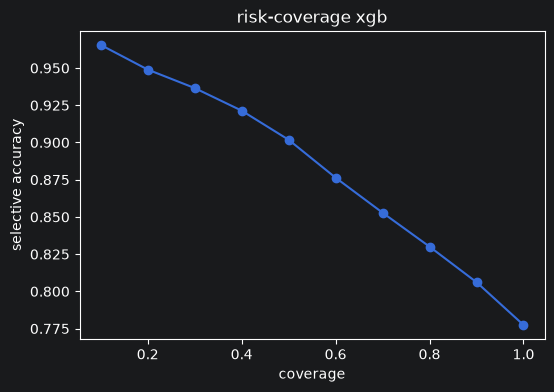

In [15]:
s = store['id']['xgb']; p, y = s['p_raw'], s['yte']
rc = risk_coverage(p, y); rc.round(4).to_csv(f'{OUT}/results/risk_coverage.csv', index=False)
print('risk-coverage (xgb)'); print(rc.round(4).to_string(index=False))
ent = entropy(p); yhat = (p >= 0.5).astype(int)
print('\nmean entropy', round(ent.mean(), 4))
print(pd.DataFrame({'group': ['correct','wrong'],
      'mean_entropy': [round(ent[yhat == y].mean(), 4), round(ent[yhat != y].mean(), 4)]}).to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4)); ax.plot(rc.coverage, rc.accuracy, 'o-')
ax.set_xlabel('coverage'); ax.set_ylabel('selective accuracy'); ax.set_title('risk-coverage xgb')
savefig(fig, 'risk_coverage_xgb')

## Consolidated summary

One JSON holding the seed, the performance, explanation, drift, and fairness tables, saved
for aggregation across the ten seeds later.

In [16]:
summary = dict(seed=SEED, pos_rate=float(df[TARGET].mean()), dropped=dropped,
               performance=perf.to_dict('records'), explanation=es.to_dict('records'),
               drift=dr.to_dict('records'), fairness_gaps=fair.to_dict('records'),
               reweigh=inter.to_dict('records'), subgroup_ece_temp=subt.to_dict('records'),
               risk_coverage=rc.to_dict('records'))
json.dump(summary, open(f'{OUT}/results/summary_seed_{SEED}.json', 'w'), indent=2)
print('saved everything under', OUT)
print('models:', len(os.listdir(f'{OUT}/models')), '| figures:', len(os.listdir(f'{OUT}/figures')),
      '| result files:', len(os.listdir(f'{OUT}/results')))

saved everything under seed_21
models: 9 | figures: 12 | result files: 14
